In [2]:
import math
import numpy as np
from numpy import linalg as LA
import quantecon as qe
import matplotlib.pyplot as plt
import pandas as pd

import random
random.seed(1234)

### part e

In [3]:
a = 0.99

p = [[1-a, a, 0],   # probability transition matrix
     [a, 0, 1-a],
     [0, 1-a, a]]

steps = np.int64(500)     # steps in MC

x_0 = 1     # starting state

num_simulations = np.int64(1E5)

# generate a Markov Chain from probability transition matrix p
mc = qe.MarkovChain(p, state_values = (1, 2, 3))

mc_lst = []     # store the markov chains

# simulate N MCs for [steps] steps
for i in range(0, num_simulations):
    # simluate Markov-chain for [steps] steps
    x_mc = mc.simulate(ts_length = steps, init = x_0)
    mc_lst.append(x_mc)

# store chains in dataframe for easier computations
mc_df = pd.DataFrame(mc_lst)

In [4]:
studied_state = 1   # state we wish to study

# fraction chains in studied_state at time n, will be plotted
# should be len(state_frac_at_n) = steps with 
state_frac_at_n = [mc_df[col].value_counts()[studied_state] / len(mc_df) for col in mc_df.columns] # 

# ensure fraction computed for each time step in chain
# ensure 100% initialized in correct starting state
if (len(state_frac_at_n) != steps) or (state_frac_at_n[0] != 1):
    print("Error.")



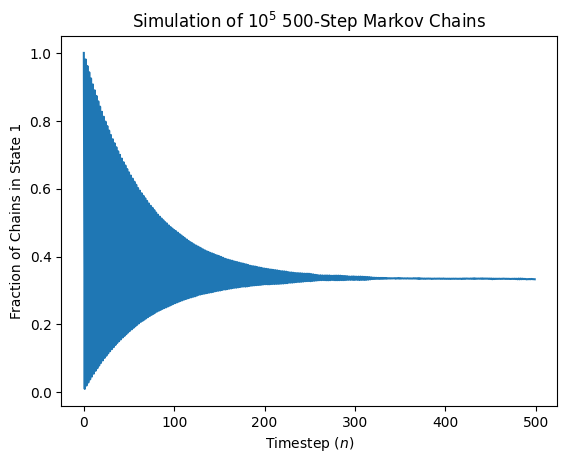

In [6]:
# plot results for all MCs
plt.plot(state_frac_at_n)
plt.title(f"Simulation of $10^5$ {steps}-Step Markov Chains")
plt.xlabel("Timestep ($n$)")
plt.ylabel(f"Fraction of Chains in State {studied_state}")
plt.show()

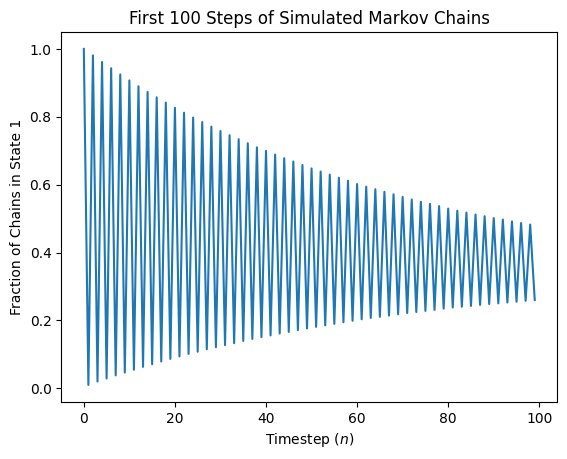

In [ ]:
max = 100
# plot results first 100 MCs
plt.plot(state_frac_at_n[0:max])
plt.title(f"First {max} Steps of Simulated Markov Chains")
plt.xlabel("Timestep ($n$)")
plt.ylabel(f"Fraction of Chains in State {studied_state}")


plt.show()

In [215]:
lambda_2 = -np.sqrt(1 - 3*a + 3*(a**2))   # second eigenvalue
lambda_3 = -lambda_2                      # third eigenvalue

gamma =  np.sqrt(1 + ((a - lambda_2) / (1-a))**2 + ((-1 + 2*a - lambda_2) / (1-a))**2)   # variable to simplify v_2 expression
alpha = np.sqrt((a-1)**2 + (a - lambda_3)**2 +(1 - 2*a + lambda_3)**2)                            # variable to simplify v_3 expression

pi = (1/3)*np.array([1, 1, 1])                                          # normalized first eigenvector, stationary distribution
v_2 = np.array([(1 - 2*a + lambda_2) / ((a-1) * gamma),                 # second eigenvector
                (a - lambda_2) / ((a-1) * gamma),
                1 / gamma
                ])
v_3 = np.array([(1 - 2*a + lambda_3) * np.abs(-1+a) / alpha * (a-1),    # third eigenvector
                (a - lambda_3) * np.abs(-1+a) / alpha * (a-1),
                np.abs(1-a) / alpha
                ])

c_2 = v_2[0]
c_3 = v_3[0]

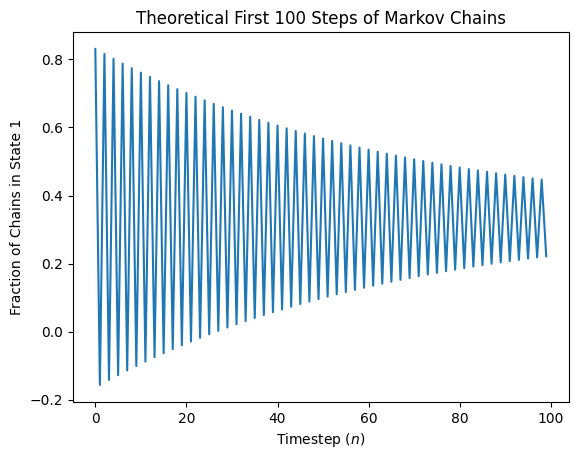

In [218]:
def q(n):
    return pi + c_2*v_2*lambda_2**n + c_3*v_3*lambda_3**n

state_frac_theory = [q(n)[0] for n in range(0,100)]     # store first element of theoretical q_n

# plot theoretical results
plt.plot(state_frac_theory)
plt.title(f"Theoretical First {max} Steps of Markov Chains")
plt.xlabel("Timestep ($n$)")
plt.ylabel(f"Fraction of Chains in State {studied_state}")


plt.show()

In [217]:
print(q(1))
print(q(1)[0])

[-0.15667936  0.82583968  0.33080659]
-0.15667935510996614
